In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [52]:
data = """Patient_ID,Age,Gender,BMI,Blood_Sugar,Income_Level,Village_Zone,Needs_Urgent_Care
P001,45,Male,24.5,110,Low,North,0
P002,50,Female,np.nan,140,Medium,South,1
P003,np.nan,Male,28.0,180,Low,East,1
P004,32,Female,22.1,95,High,North,0
P005,60,Male,31.2,np.nan,Medium,West,1
P006,28,Female,19.5,88,Low,South,0
P007,np.nan,Male,26.4,105,High,East,0
P008,55,Female,29.8,160,Low,np.nan,1
P009,40,Male,25.0,np.nan,Medium,North,0
P010,65,Female,33.1,200,Low,West,1
P011,35,Male,27.5,100,High,South,0
P012,np.nan,Female,np.nan,115,Medium,East,0
"""

with open("rural_health_data.csv", "w") as file:
    file.write(data.replace("np.nan", ""))

df = pd.read_csv("rural_health_data.csv")
print(df.head())

  Patient_ID   Age  Gender   BMI  Blood_Sugar Income_Level Village_Zone  \
0       P001  45.0    Male  24.5        110.0          Low        North   
1       P002  50.0  Female   NaN        140.0       Medium        South   
2       P003   NaN    Male  28.0        180.0          Low         East   
3       P004  32.0  Female  22.1         95.0         High        North   
4       P005  60.0    Male  31.2          NaN       Medium         West   

   Needs_Urgent_Care  
0                  0  
1                  1  
2                  1  
3                  0  
4                  1  


In [53]:
df

,Patient_ID,Age,Gender,BMI,Blood_Sugar,Income_Level,Village_Zone,Needs_Urgent_Care
0,P001,45.0,Male,24.5,110.0,Low,North,0
1,P002,50.0,Female,NaN,140.0,Medium,South,1
2,P003,NaN,Male,28.0,180.0,Low,East,1
3,P004,32.0,Female,22.1,95.0,High,North,0
4,P005,60.0,Male,31.2,NaN,Medium,West,1
5,P006,28.0,Female,19.5,88.0,Low,South,0
6,P007,NaN,Male,26.4,105.0,High,East,0
7,P008,55.0,Female,29.8,160.0,Low,NaN,1
8,P009,40.0,Male,25.0,NaN,Medium,North,0
9,P010,65.0,Female,33.1,200.0,Low,West,1


In [54]:
df.drop(columns='Patient_ID', inplace=True)

In [55]:
numerical_features = ['Age', 'BMI', 'Blood_Sugar']
categorical_features = ['Gender', 'Village_Zone']
ordinal_features = ['Income_Level']

In [56]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

In [57]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False))
])

In [58]:
ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[['Low', 'Medium', 'High']]))
])

In [59]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features),
    ('ord', ordinal_transformer, ordinal_features)
])

In [60]:
new_df = preprocessor.fit_transform(df)

In [61]:
new_df

array([[ 45.  ,  24.5 , 110.  ,   0.  ,   1.  ,   0.  ,   1.  ,   0.  ,
          0.  ,   0.  ],
       [ 50.  ,  26.95, 140.  ,   1.  ,   0.  ,   0.  ,   0.  ,   1.  ,
          0.  ,   1.  ],
       [ 45.  ,  28.  , 180.  ,   0.  ,   1.  ,   1.  ,   0.  ,   0.  ,
          0.  ,   0.  ],
       [ 32.  ,  22.1 ,  95.  ,   1.  ,   0.  ,   0.  ,   1.  ,   0.  ,
          0.  ,   2.  ],
       [ 60.  ,  31.2 , 112.5 ,   0.  ,   1.  ,   0.  ,   0.  ,   0.  ,
          1.  ,   1.  ],
       [ 28.  ,  19.5 ,  88.  ,   1.  ,   0.  ,   0.  ,   0.  ,   1.  ,
          0.  ,   0.  ],
       [ 45.  ,  26.4 , 105.  ,   0.  ,   1.  ,   1.  ,   0.  ,   0.  ,
          0.  ,   2.  ],
       [ 55.  ,  29.8 , 160.  ,   1.  ,   0.  ,   1.  ,   0.  ,   0.  ,
          0.  ,   0.  ],
       [ 40.  ,  25.  , 112.5 ,   0.  ,   1.  ,   0.  ,   1.  ,   0.  ,
          0.  ,   1.  ],
       [ 65.  ,  33.1 , 200.  ,   1.  ,   0.  ,   0.  ,   0.  ,   0.  ,
          1.  ,   0.  ],
       [ 35.  ,  27.5 , 100.  

In [62]:
ohe_columns = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)

In [63]:
final_columns = numerical_features + list(ohe_columns) + ordinal_features
final_df = pd.DataFrame(new_df, columns=final_columns)

In [64]:
final_df

,Age,BMI,Blood_Sugar,Gender_Female,Gender_Male,Village_Zone_East,Village_Zone_North,Village_Zone_South,Village_Zone_West,Income_Level
0,45.0,24.50,110.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,50.0,26.95,140.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2,45.0,28.00,180.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,32.0,22.10,95.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0
4,60.0,31.20,112.5,0.0,1.0,0.0,0.0,0.0,1.0,1.0
5,28.0,19.50,88.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
6,45.0,26.40,105.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0
7,55.0,29.80,160.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
8,40.0,25.00,112.5,0.0,1.0,0.0,1.0,0.0,0.0,1.0
9,65.0,33.10,200.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [65]:
final_df['Needs_Urgent_Care'] = df['Needs_Urgent_Care'].values

In [66]:
final_df

,Age,BMI,Blood_Sugar,Gender_Female,Gender_Male,Village_Zone_East,Village_Zone_North,Village_Zone_South,Village_Zone_West,Income_Level,Needs_Urgent_Care
0,45.0,24.50,110.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0
1,50.0,26.95,140.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1
2,45.0,28.00,180.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1
3,32.0,22.10,95.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0,0
4,60.0,31.20,112.5,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1
5,28.0,19.50,88.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0
6,45.0,26.40,105.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0,0
7,55.0,29.80,160.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1
8,40.0,25.00,112.5,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0
9,65.0,33.10,200.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1


In [67]:
correlation = final_df.corr()

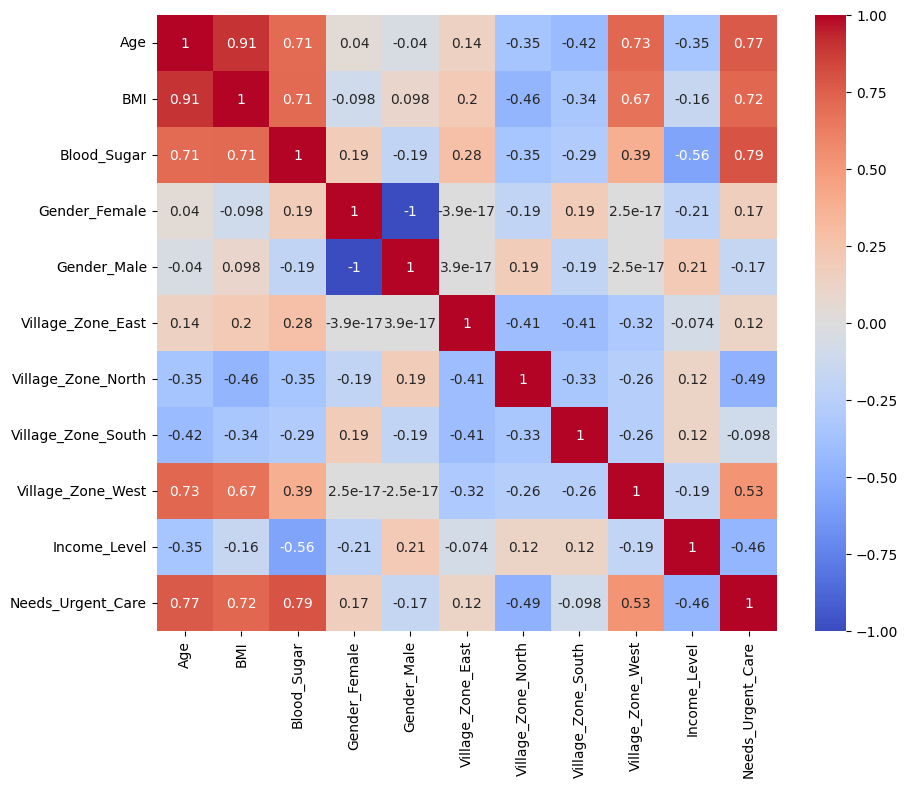

In [68]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.show()

In [69]:
X_best = df[numerical_features + categorical_features + ordinal_features]
y_best = df['Needs_Urgent_Care']

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X_best, y_best, test_size=0.2, random_state=42)

In [72]:
ml_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

In [73]:
ml_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'BMI',
                                                   'Blood_Sugar']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(sparse_output=False))]),
                                                  ['Gender', 'Village_Zone']),
                                                 ('ord',
                                                  Pipeline(steps=[('ordinal',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High']]))]),
                                                  ['Income_Level'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [74]:
accuracy = ml_pipeline.score(X_test, y_test)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 100.00%


In [75]:
train_accuracy = ml_pipeline.score(X_train, y_train)

test_accuracy = ml_pipeline.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")

if train_accuracy > (test_accuracy + 0.10):
    print("Warning: Your model is likely overfitting!")
else:
    print("Your model is generalizing well.")

Training Accuracy: 100.00%
Testing Accuracy: 100.00%
Your model is generalizing well.


In [76]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(ml_pipeline, X_best, y_best, cv=5)

print(f"5 time accuracy: {scores}")
print(f"Real accuracy mean: {scores.mean() * 100:.2f}%")

5 time accuracy: [0.66666667 0.66666667 1.         1.         1.        ]
Real accuracy mean: 86.67%
